In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [3]:
df = pd.read_csv(r"D:\tc\IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [5]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [6]:
df.size

100000

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [32]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

texts = df['review'].values
labels = df['sentiment'].values


In [9]:
labels

array([1, 1, 1, ..., 0, 0, 0], shape=(50000,))

In [10]:
# splitting the data 

X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42
)

In [12]:
# Tokenizer


vocab_size = 10000  

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)


In [13]:
vocab_size

10000

In [14]:
#convert text to sequence

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_seq[0][:20]


[198,
 49,
 11,
 802,
 2161,
 535,
 303,
 2,
 108,
 1908,
 2039,
 4325,
 6551,
 3,
 816,
 4845,
 13,
 1,
 2,
 1]

In [17]:
# Padding


max_length = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

X_train_pad.shape


(40000, 200)

In [18]:
#Building the Tensorflow model

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length),
    LSTM(64),
    Dense(1, activation='sigmoid')
])
model

C:\Users\sahas\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


<Sequential name=sequential, built=False>

In [19]:
# compile the model


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [23]:
# summary of the model

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (32, 200, 128)              │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (32, 64)                    │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 1)                     │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,988,421 (15.21 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,658,948 (10.14 MB)

In [24]:
#Training the model

history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 68s 68ms/step - accuracy: 0.9402 - loss: 0.1697 - val_accuracy: 0.8840 - val_loss: 0.3215
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 84s 69ms/step - accuracy: 0.9598 - loss: 0.1205 - val_accuracy: 0.8810 - val_loss: 0.3407
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 68s 68ms/step - accuracy: 0.9717 - loss: 0.0926 - val_accuracy: 0.8764 - val_loss: 0.3875
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 75s 75ms/step - accuracy: 0.9814 - loss: 0.0660 - val_accuracy: 0.8727 - val_loss: 0.5131
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 69s 69ms/step - accuracy: 0.9852 - loss: 0.0521 - val_accuracy: 0.8645 - val_loss: 0.4947


In [28]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test_pad, y_test, verbose=1)

print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8686 - loss: 0.4755
Test Loss: 0.47545570135116577
Test Accuracy: 0.8686000108718872


In [29]:
# Predict on test data
y_pred = model.predict(X_test_pad)

# If binary classification
y_pred_classes = (y_pred > 0.5).astype("int32")

# Classification report
from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.82      0.86      4961
           1       0.84      0.92      0.88      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [31]:
#Predict the new text
sample_text = ["This movie was boring and too long"]

seq = tokenizer.texts_to_sequences(sample_text)
pad = pad_sequences(seq, maxlen=max_length, padding='post')

prediction = model.predict(pad)

score = prediction[0][0]

if score > 0.5:
    print("Positive Review")
else:
    print("Negative Review")

print("Prediction Score:", score)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Negative Review
Prediction Score: 0.0050841053


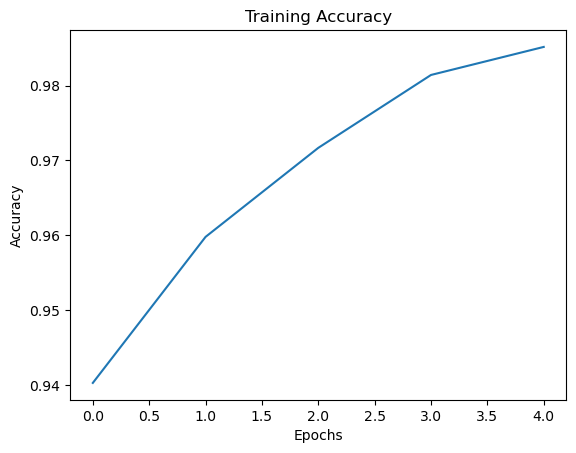

In [40]:
#univariant
# For accuracy
import matplotlib.pyplot as plt
plt.figure()
plt.plot(history.history['accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.show()

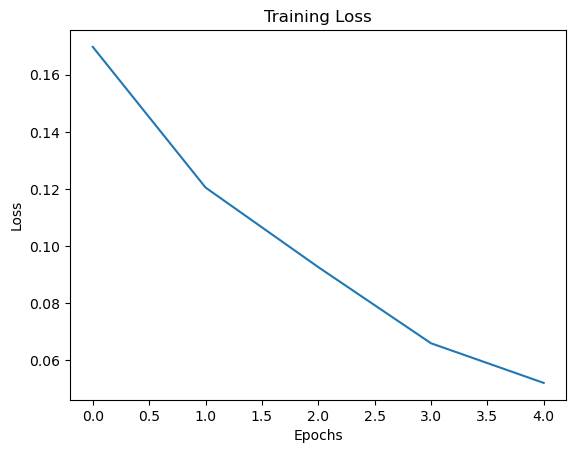

In [35]:
# for loss

plt.figure()
plt.plot(history.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()


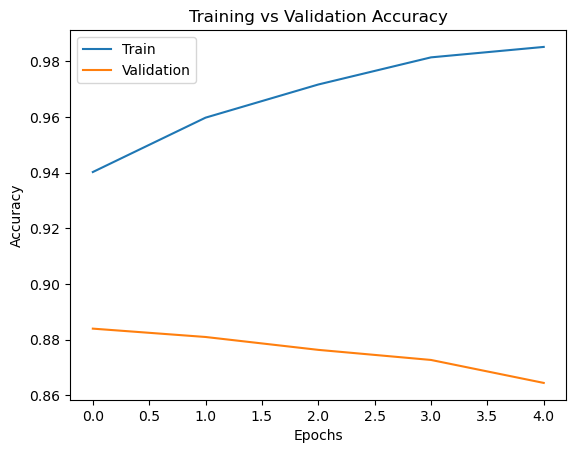

In [42]:
# Training vs validation accuracy (bivariant)

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


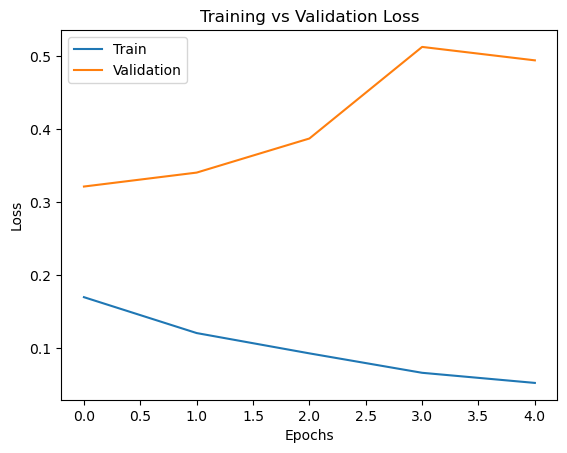

In [38]:
#Training vs validation loss

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(['Train', 'Validation'])
plt.show()


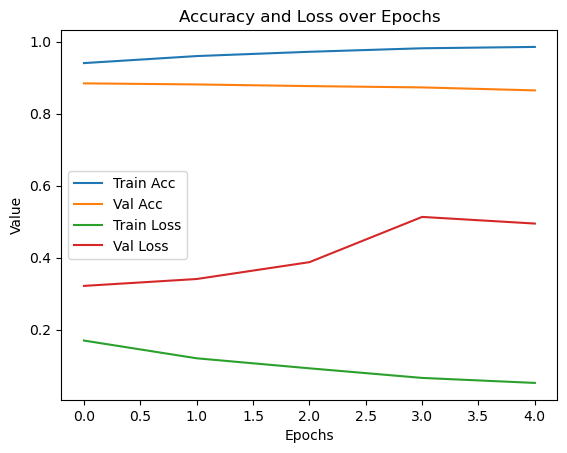

In [41]:
#Accuracy and loss together (Multivariant)

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Accuracy and Loss over Epochs')
plt.legend(['Train Acc', 'Val Acc', 'Train Loss', 'Val Loss'])
plt.show()


Conclusion  :

1. This project successfully implemented a Text Classification system using machine learning techniques.

2. Raw textual data was effectively preprocessed through cleaning, tokenization, and vectorization, which improved model performance.

3. Feature extraction techniques such as TF-IDF / embeddings helped convert unstructured text into meaningful numerical representations.

4. The trained classification model was able to accurately categorize text data based on learned patterns.

5. Visual analysis (univariate, bivariate, and multivariate plots) helped in understanding data distribution, class balance, and feature influence.

6. Performance evaluation demonstrated that the model is efficient and reliable for text-based prediction tasks.

7. The project validates the importance of natural language processing (NLP) in handling real-world textual data.

Overall, the system provides a strong foundation for automated text analysis applications such as sentiment analysis, spam detection, and document classification.